In [192]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [193]:
movies = pd.read_csv('../../datos/movie_recomendations/movies_cleaned.csv')
movies

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1995.0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1995.0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57233,209155,Santosh Subramaniam (2008),1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,2008.0
57234,209157,We (2018),0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2018.0
57235,209159,Window of the Soul (2001),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2001.0
57236,209163,Bad Poems (2018),0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,2018.0


In [194]:
movies = movies.sample(10000)
movies.reset_index(inplace=True)
movies.drop(columns=['index'], inplace=True)
movies

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year
0,3368,"Big Country, The (1958)",0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1958.0
1,143119,Mansion of the Doomed (1976),0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1976.0
2,7234,"Strada, La (1954)",0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1954.0
3,2576,"Love, etc. (1996)",0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1996.0
4,71374,Hellraiser: Hellworld (2005),0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,94280,Spud (2010),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2010.0
9996,32535,No One Writes to the Colonel (El coronel no ti...,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1999.0
9997,462,"Good Man in Africa, A (1994)",1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1994.0
9998,135434,Nanny Cam (2014),0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,2014.0


In [195]:
def recommend_movies(movie_title, df, similarity_matrix, top_n=5):
    # Encontrar el índice de la película dada
    idx = df[df['title'] == movie_title].index[0]
    
    # Obtener similitudes con otras películas
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Ordenar por mayor similitud (excluyendo la propia película)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    # Obtener los títulos recomendados
    recommended_indices = [i[0] for i in sim_scores]
    return df.loc[recommended_indices]
    #return df.loc[recommended_indices, ['title']]

In [196]:
# Normalizar el año
scaler = MinMaxScaler(feature_range=(-1, 1))
movies['year_scaled'] = scaler.fit_transform(movies[['year']])

In [197]:
genre_columns = movies.columns[2:-2]
X_genres = movies[genre_columns.tolist() + ['year_scaled']]

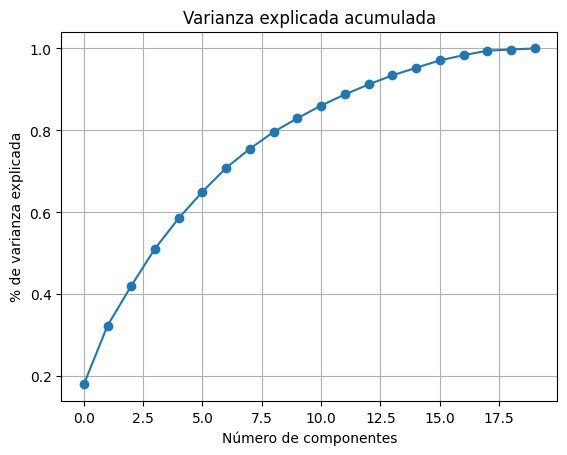

In [198]:
pca_full = PCA().fit(X_genres)
plt.plot(pca_full.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza explicada acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('% de varianza explicada')
plt.grid()
plt.show()

In [199]:
componentes = 10

# Aplicamos PCA
pca = PCA(n_components=componentes)
X_genres_pca = pca.fit_transform(X_genres)

# Convertimos los resultados a un DataFrame
final_df = pd.DataFrame(X_genres_pca, columns=[f'genre_pca_{i+1}' for i in range(componentes)])

In [200]:
similarity_matrix = cosine_similarity(final_df)
similarity_matrix

array([[ 1.        ,  0.22898293,  0.13850786, ...,  0.04480058,
        -0.37394764,  0.39880934],
       [ 0.22898293,  1.        , -0.00439294, ...,  0.05988115,
        -0.25489049,  0.32562957],
       [ 0.13850786, -0.00439294,  1.        , ..., -0.23330581,
         0.09530532,  0.13582261],
       ...,
       [ 0.04480058,  0.05988115, -0.23330581, ...,  1.        ,
        -0.33211975,  0.61145201],
       [-0.37394764, -0.25489049,  0.09530532, ..., -0.33211975,
         1.        , -0.41325223],
       [ 0.39880934,  0.32562957,  0.13582261, ...,  0.61145201,
        -0.41325223,  1.        ]])

In [201]:
movie_test = movies.loc[0]
movie_test

movieId                           3368
title          Big Country, The (1958)
Action                               0
Adventure                            0
Animation                            0
Children                             0
Comedy                               0
Crime                                0
Documentary                          0
Drama                                0
Fantasy                              0
Film-Noir                            0
Horror                               0
IMAX                                 0
Musical                              0
Mystery                              0
Romance                              1
Sci-Fi                               0
Thriller                             0
War                                  0
Western                              1
year                            1958.0
year_scaled                    0.03937
Name: 0, dtype: object

In [202]:
recomendaciones = recommend_movies(movie_test['title'], movies, similarity_matrix)
recomendaciones

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year,year_scaled
2001,108542,Wyoming Renegades (1954),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1954.0,-0.023622
4827,147972,The Desert Song (1953),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1953.0,-0.039370
4204,133618,That Wonderful Urge (1948),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1948.0,-0.118110
2983,68163,Lust for Gold (1949),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1949.0,-0.102362
3554,186157,Diary of a Nudist (1961),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1961.0,0.086614
